# 03 Recommender System: Zomato Bangalore Restaurant Recommender

**Objective.** Build a practical restaurant recommender system using the Zomato Bangalore dataset. Since the dataset does not contain user-level ratings or user-item interactions, this notebook uses a **content-based recommender** supported by popularity and quality signals.

The recommender answers this business question:

> Given a restaurant selected by a user, which other restaurants are most similar and worth recommending?

The notebook includes:

1. Data loading and quality checks  
2. Cleaning of ratings, cost, and restaurant metadata  
3. Popularity-adjusted weighted rating  
4. Text feature engineering for restaurant similarity  
5. TF-IDF + cosine similarity recommender  
6. Hybrid ranking using similarity, weighted rating, and votes  
7. QA test cases with comments per result  
8. Interpretation and improvement recommendations

## 1. Import Libraries and Global Settings

The main modelling approach is **TF-IDF vectorization** combined with **cosine similarity**. TF-IDF converts restaurant descriptions into numerical vectors, while cosine similarity measures how similar two restaurants are based on cuisine, restaurant type, location, and liked dishes.

In [1]:
import os
import re
import ast
import warnings
from pathlib import Path
from difflib import get_close_matches

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

## 2. Load the Data

In [35]:
DATA_PATH = "/Users/wpmangapot/Desktop/WorkFolder/Projects/stat280_pml/data/zomato.csv"


if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
else:
    raise FileNotFoundError(
        "Dataset not found. Place zomato.csv in the notebook folder or update DATA_PATH."
    )

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banashankari?context=eyJzZSI6eyJlIjpbNTg2OTQsIjE4Mzc1NDc0IiwiNTkwOTAiLCIxODM4...,"942, 21st Main Road, 2nd Stage, Banashankari, Bangalore",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings a...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephant-banashankari?context=eyJzZSI6eyJlIjpbIjU4Njk0IiwxODM3NTQ3NCwiNTkwOTA...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th Block, Kathriguppe, 3rd Stage, Banashankari, Bangalore",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for dinner with family. Turned out to be a good choose suitable for all ages ...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?context=eyJzZSI6eyJlIjpbIjU4Njk0IiwiMTgzNzU0NzQiLDU5MDkwLCIxODM4Mjk0NCIsIj...,"1112, Next to KIMS Medical College, 17th Cross, 2nd Stage, Banashankari, Bangalore",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that good enough and it's not a pocket friendly cafe and the quantity is no...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi-bhojana-banashankari?context=eyJzZSI6eyJlIjpbIjU4Njk0IiwiMTgzNzU0NzQi...,"1st Floor, Annakuteera, 3rd Stage, Banashankari, Bangalore",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper Karnataka style full meals. Been there twice and was fully satisfied....",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village-basavanagudi?context=eyJzZSI6eyJlIjpbIjU4Njk0IiwiMTgzNzU0NzQiLCI1OTA5...,"10, 3rd Floor, Lakshmi Associates, Gandhi Bazaar Main Road, Above Reliance Trends, Basavanagudi, Bangalore",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant in neighbourhood. Buffet system is properly arranged. Variety of dishe...",[],Buffet,Banashankari


## 3. Data Quality Check

Before building a recommender, we check missingness and cardinality. This is important because recommendation quality depends heavily on how complete and meaningful the restaurant metadata is.

In [36]:
def data_quality_report(dataframe):
    report = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),
        "missing_count": dataframe.isna().sum(),
        "missing_pct": dataframe.isna().mean(),
        "unique_count": dataframe.nunique(dropna=True)
    })
    return report.sort_values("missing_pct", ascending=False)

quality_report = data_quality_report(df_raw)
quality_report

,dtype,missing_count,missing_pct,unique_count
dish_liked,object,28078,0.542916,5271
rate,object,7775,0.150337,64
phone,object,1208,0.023358,14926
approx_cost(for two people),object,346,0.006690,70
rest_type,object,227,0.004389,93
cuisines,object,45,0.000870,2723
location,object,21,0.000406,93
listed_in(type),object,0,0.000000,7
menu_item,object,0,0.000000,9098
reviews_list,object,0,0.000000,22513


In [38]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("Unique restaurant names:", df_raw["name"].nunique())
print("Unique locations:", df_raw["location"].nunique())
print("Unique cuisines strings:", df_raw["cuisines"].nunique())

Duplicate rows: 0
Unique restaurant names: 8792
Unique locations: 93
Unique cuisines strings: 2723


### Data Quality Interpretation

Expected issue: `dish_liked` usually has high missingness in this dataset. We should **not drop it**, because it is a strong food-preference signal when available. However, the recommender should not depend on it alone. More complete fields such as `cuisines`, `rest_type`, `location`, and `listed_in(type)` should carry the main content signal.

## 4. Clean and Standardize Data

We clean the dataset by:

- removing duplicate restaurant records where appropriate,
- converting `rate` from text to numeric,
- converting `approx_cost(for two people)` to numeric,
- filling missing restaurant metadata with neutral placeholders,
- keeping `dish_liked` as an optional supporting signal.

In [39]:
df = df_raw.copy()

# Standardize column names for easier handling
# Keep original names readable but create clean helper columns.
df.columns = df.columns.str.strip()

# Drop exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Clean rating column
if "rate" in df.columns:
    df["rate_clean"] = (
        df["rate"]
        .astype(str)
        .str.replace("/5", "", regex=False)
        .str.replace("NEW", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip()
    )
    df["rate_clean"] = pd.to_numeric(df["rate_clean"], errors="coerce")
else:
    df["rate_clean"] = np.nan

# Clean cost column
cost_col = "approx_cost(for two people)"
if cost_col in df.columns:
    df["cost_clean"] = (
        df[cost_col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df["cost_clean"] = pd.to_numeric(df["cost_clean"], errors="coerce")
else:
    df["cost_clean"] = np.nan

# Fill numeric missing values using robust medians
df["rate_clean"] = df["rate_clean"].fillna(df["rate_clean"].median())
df["cost_clean"] = df["cost_clean"].fillna(df["cost_clean"].median())

# Fill text fields
text_cols = ["name", "location", "rest_type", "cuisines", "dish_liked", "listed_in(type)", "listed_in(city)"]
for col in text_cols:
    if col in df.columns:
        fill_value = "" if col == "dish_liked" else "Unknown"
        df[col] = df[col].fillna(fill_value).astype(str)

# Clean votes
if "votes" in df.columns:
    df["votes"] = pd.to_numeric(df["votes"], errors="coerce").fillna(0)
else:
    df["votes"] = 0

print("Cleaned shape:", df.shape)
df[["name", "location", "cuisines", "rest_type", "rate_clean", "votes", "cost_clean"]].head()

Cleaned shape: (51717, 19)


,name,location,cuisines,rest_type,rate_clean,votes,cost_clean
0,Jalsa,Banashankari,"North Indian, Mughlai, Chinese",Casual Dining,4.1,775,800.0
1,Spice Elephant,Banashankari,"Chinese, North Indian, Thai",Casual Dining,4.1,787,800.0
2,San Churro Cafe,Banashankari,"Cafe, Mexican, Italian","Cafe, Casual Dining",3.8,918,800.0
3,Addhuri Udupi Bhojana,Banashankari,"South Indian, North Indian",Quick Bites,3.7,88,300.0
4,Grand Village,Basavanagudi,"North Indian, Rajasthani",Casual Dining,3.8,166,600.0


## 5. Create Restaurant-Level Dataset

The raw Zomato dataset may contain multiple rows for the same restaurant because the same restaurant can appear under different listing categories or city pages. For recommendations, we aggregate to a cleaner restaurant-level table.

In [40]:
restaurant_key = ["name", "location"]

restaurants = (
    df.groupby(restaurant_key, as_index=False)
    .agg({
        "rate_clean": "mean",
        "votes": "max",
        "cost_clean": "median",
        "rest_type": lambda x: ", ".join(sorted(set([v for v in x if v and v != "Unknown"]))) or "Unknown",
        "cuisines": lambda x: ", ".join(sorted(set([v for v in x if v and v != "Unknown"]))) or "Unknown",
        "dish_liked": lambda x: ", ".join(sorted(set([v for v in x if v]))),
        "listed_in(type)": lambda x: ", ".join(sorted(set([v for v in x if v and v != "Unknown"]))) or "Unknown",
        "listed_in(city)": lambda x: ", ".join(sorted(set([v for v in x if v and v != "Unknown"]))) or "Unknown"
    })
)

restaurants = restaurants.rename(columns={
    "rate_clean": "rating",
    "cost_clean": "cost_for_two"
})

restaurants["restaurant_id"] = np.arange(len(restaurants))

print("Restaurant-level shape:", restaurants.shape)
restaurants.head()

Restaurant-level shape: (12151, 11)


,name,location,rating,votes,cost_for_two,rest_type,cuisines,dish_liked,listed_in(type),listed_in(city),restaurant_id
0,#FeelTheROLL,Bellandur,3.4,7,200.0,Quick Bites,Fast Food,,Delivery,"Bellandur, Sarjapur Road",0
1,#L-81 Cafe,HSR,3.9,48,400.0,Quick Bites,"Fast Food, Beverages",Burgers,"Delivery, Dine-out","BTM, HSR, Koramangala 4th Block, Koramangala 5th Block, Koramangala 6th Block, Koramangala 7th Block",1
2,#Vibes Restro,Electronic City,3.7,0,700.0,Casual Dining,"Continental, Chinese, Italian",,"Buffet, Delivery, Dine-out",Electronic City,2
3,#refuel,Bannerghatta Road,3.7,37,400.0,Cafe,"Cafe, Beverages","Thick Shakes, Sandwiches, Pasta, Mocktails","Cafes, Delivery, Dine-out",Bannerghatta Road,3
4,'Brahmins' Thatte Idli,Basaveshwara Nagar,3.7,0,100.0,Quick Bites,South Indian,,Dine-out,Rajajinagar,4


## 6. Create Weighted Rating

A restaurant with a 4.8 rating from 5 votes should not automatically rank higher than a restaurant with a 4.4 rating from 2,000 votes. To handle this, we use a Bayesian-style weighted rating.

Formula:

\[
Weighted\ Rating = 
rac{v}{v+m}R + 
rac{m}{v+m}C
\]

Where:

- \(R\) = restaurant average rating  
- \(v\) = number of votes  
- \(C\) = global average rating  
- \(m\) = minimum vote threshold, usually a selected percentile of vote counts

In [41]:
C = restaurants["rating"].mean()
m = restaurants["votes"].quantile(0.75)

restaurants["weighted_rating"] = (
    (restaurants["votes"] / (restaurants["votes"] + m)) * restaurants["rating"] +
    (m / (restaurants["votes"] + m)) * C
)

restaurants[["name", "location", "rating", "votes", "weighted_rating"]].sort_values(
    "weighted_rating", ascending=False
).head(10)

,name,location,rating,votes,weighted_rating
1799,Byg Brewski Brewing Company,Sarjapur Road,4.9,16832,4.890691
167,AB's - Absolute Barbecues,BTM,4.9,6490,4.876139
3754,Flechazo,Whitefield,4.9,3004,4.849564
810,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9,2256,4.833726
6909,Milano Ice Cream,Indiranagar,4.9,2090,4.828762
8443,Punjab Grill,Malleshwaram,4.9,1985,4.825218
1232,Belgian Waffle Factory,Brigade Road,4.9,1750,4.815851
169,AB's - Absolute Barbecues,Marathahalli,4.8,12121,4.788139
10796,The Black Pearl,Marathahalli,4.8,7284,4.780396
2454,Chili's American Grill & Bar,Malleshwaram,4.8,6470,4.777977


## 7. Feature Engineering for Content-Based Recommendation

The recommender uses restaurant metadata as text. More important fields are repeated to give them higher weight in TF-IDF.

Feature logic:

- `cuisines`: strongest similarity signal
- `rest_type`: important for dining format
- `location`: useful when users prefer nearby places
- `listed_in(type)`: supports use-case context such as delivery, dine-out, buffet, desserts, etc.
- `dish_liked`: valuable but incomplete, so used as supporting signal only

In [42]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9, ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ["name", "location", "rest_type", "cuisines", "dish_liked", "listed_in(type)"]:
    restaurants[col + "_clean"] = restaurants[col].apply(clean_text)

# Weighted text representation
restaurants["content_features"] = (
    (restaurants["cuisines_clean"] + " ") * 4 +
    (restaurants["rest_type_clean"] + " ") * 3 +
    (restaurants["location_clean"] + " ") * 2 +
    (restaurants["listed_in(type)_clean"] + " ") * 2 +
    (restaurants["dish_liked_clean"] + " ") * 1
)

restaurants[["name", "location", "content_features"]].head()

,name,location,content_features
0,#FeelTheROLL,Bellandur,fast food fast food fast food fast food quick bites quick bites quick bites bellandur bellandur delivery delivery
1,#L-81 Cafe,HSR,"fast food, beverages fast food, beverages fast food, beverages fast food, beverages quick bites quick bites quick bi..."
2,#Vibes Restro,Electronic City,"continental, chinese, italian continental, chinese, italian continental, chinese, italian continental, chinese, ital..."
3,#refuel,Bannerghatta Road,"cafe, beverages cafe, beverages cafe, beverages cafe, beverages cafe cafe cafe bannerghatta road bannerghatta road c..."
4,'Brahmins' Thatte Idli,Basaveshwara Nagar,south indian south indian south indian south indian quick bites quick bites quick bites basaveshwara nagar basaveshw...


## 8. Build TF-IDF Matrix

We use `ngram_range=(1,2)` so the model can capture both single words and short phrases such as `north indian`, `ice cream`, and `quick bites`.

In [43]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf.fit_transform(restaurants["content_features"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (12151, 8547)


## 9. Scale Quality Signals

The final recommender should not rely on similarity alone. A restaurant may be very similar but poorly rated. We therefore create scaled quality indicators for weighted rating and votes.

In [44]:
scaler = MinMaxScaler()
restaurants[["weighted_rating_scaled", "votes_scaled", "cost_scaled"]] = scaler.fit_transform(
    restaurants[["weighted_rating", "votes", "cost_for_two"]]
)

restaurants[["name", "rating", "votes", "weighted_rating", "weighted_rating_scaled", "votes_scaled"]].head()

,name,rating,votes,weighted_rating,weighted_rating_scaled,votes_scaled
0,#FeelTheROLL,3.4,7,3.634103,0.496888,0.000416
1,#L-81 Cafe,3.9,48,3.716872,0.530027,0.002852
2,#Vibes Restro,3.7,0,3.647109,0.502095,0.000000
3,#refuel,3.7,37,3.659115,0.506902,0.002198
4,'Brahmins' Thatte Idli,3.7,0,3.647109,0.502095,0.000000


## 10. Recommendation Function

The function below returns similar restaurants based on content similarity, then ranks candidates using a hybrid score:

\[
Final\ Score = 0.50(Similarity) + 0.30(Weighted\ Rating) + 0.20(Votes)
\]

This balances relevance and quality.

In [45]:
def find_restaurant_matches(query_name, query_location=None, top_k=10):
    """Find restaurants matching the user's query text."""
    query_name_clean = query_name.lower().strip()
    candidates = restaurants[restaurants["name"].str.lower().str.contains(query_name_clean, regex=False)]
    
    if query_location is not None:
        query_location_clean = query_location.lower().strip()
        loc_candidates = candidates[candidates["location"].str.lower().str.contains(query_location_clean, regex=False)]
        if len(loc_candidates) > 0:
            candidates = loc_candidates
    
    return candidates.head(top_k)


def recommend_restaurants(
    query_name,
    query_location=None,
    n_recommendations=10,
    same_location_only=False,
    max_cost=None,
    similarity_weight=0.50,
    rating_weight=0.30,
    votes_weight=0.20
):
    """
    Recommend restaurants similar to the selected restaurant.
    
    Parameters
    ----------
    query_name : str
        Restaurant name entered by the user.
    query_location : str, optional
        Location to disambiguate restaurants with similar names.
    n_recommendations : int
        Number of recommendations to return.
    same_location_only : bool
        If True, only recommend restaurants in the same location.
    max_cost : float, optional
        If provided, only recommend restaurants with cost_for_two <= max_cost.
    similarity_weight, rating_weight, votes_weight : float
        Weights used for final ranking score.
    """
    matches = find_restaurant_matches(query_name, query_location=query_location)
    
    if matches.empty:
        return pd.DataFrame({"message": ["No matching restaurant found. Try checking spelling or removing location filter."]})
    
    query_idx = matches.iloc[0]["restaurant_id"]
    query_row = restaurants.loc[restaurants["restaurant_id"] == query_idx].iloc[0]
    
    # Calculate cosine similarity of selected restaurant against all restaurants
    similarity_scores = cosine_similarity(tfidf_matrix[query_idx], tfidf_matrix).flatten()
    
    recs = restaurants.copy()
    recs["similarity"] = similarity_scores
    
    # Remove the query restaurant itself
    recs = recs[recs["restaurant_id"] != query_idx]
    
    # Optional filters
    if same_location_only:
        recs = recs[recs["location"] == query_row["location"]]
    
    if max_cost is not None:
        recs = recs[recs["cost_for_two"] <= max_cost]
    
    # Hybrid final score
    recs["final_score"] = (
        similarity_weight * recs["similarity"] +
        rating_weight * recs["weighted_rating_scaled"] +
        votes_weight * recs["votes_scaled"]
    )
    
    output_cols = [
        "name", "location", "cuisines", "rest_type", "rating", "votes",
        "cost_for_two", "weighted_rating", "similarity", "final_score"
    ]
    
    return recs.sort_values("final_score", ascending=False).head(n_recommendations)[output_cols].reset_index(drop=True)

## 11. Test the Recommender

Example query. You may replace the restaurant and location with any restaurant in the dataset.

In [47]:
recommend_restaurants(
    query_name="Biryani",
    query_location="HSR",
    n_recommendations=10
)

,name,location,cuisines,rest_type,rating,votes,cost_for_two,weighted_rating,similarity,final_score
0,Brajwasi Catering Service,HSR,"North Indian, Chinese",Delivery,3.700000,0,200.0,3.647109,1.000000,0.650629
1,It's My Meal Food Service,HSR,"North Indian, Chinese",Delivery,3.700000,0,300.0,3.647109,1.000000,0.650629
2,Brown Box,HSR,"North Indian, Chinese",Delivery,3.700000,0,400.0,3.647109,1.000000,0.650629
3,Kia's Kitchen,HSR,"North Indian, Chinese",Delivery,3.500000,12,600.0,3.634316,1.000000,0.649235
4,The Kitchen Story,HSR,"North Indian, Chinese",Delivery,3.283333,19,300.0,3.599441,1.000000,0.645129
5,Taza Khaana,HSR,"Chinese, North Indian",Delivery,3.066667,175,450.0,3.309642,0.947600,0.585974
6,Maggie Point,Whitefield,"North Indian, Chinese",Delivery,3.700000,0,300.0,3.647109,0.833623,0.567440
7,Ind Foodies,Whitefield,"North Indian, Chinese",Delivery,3.700000,0,300.0,3.647109,0.833623,0.567440
8,Shukno Lanka,Whitefield,"North Indian, Chinese",Delivery,3.700000,0,400.0,3.647109,0.833623,0.567440
9,Kahaani Cafe And Restaurant,HSR,"North Indian, Chinese",Quick Bites,3.700000,0,300.0,3.647109,0.826158,0.563708


## 12. Batch QA Test Cases

A recommender system should not only work for one example. We test multiple restaurants and summarize quality using:

- `avg_similarity`: how close the recommendations are to the selected restaurant
- `avg_rating`: average raw rating of recommendations
- `avg_weighted_rating`: quality-adjusted rating
- `unique_locations`: location diversity
- `unique_cuisine_strings`: cuisine diversity

In [48]:
test_cases = [
    ("Bombay Kulfis", "Ulsoor"),
    ("The Rice Company", "HSR"),
    ("Aliyar Cafe Sweet Palace", "Jayanagar"),
    ("Promac Foods", "Shanti Nagar"),
    ("Silbatti", "HSR"),
    ("The Courtyard", "Shanti Nagar"),
    ("Cake of the Day", "HSR"),
    ("Biryani treat", "HSR"),
    ("Donne Biriyani Mane", "Domlur"),
    ("Indian Aroma Cafe", "Whitefield")
]

qa_rows = []

for restaurant_name, location in test_cases:
    recs = recommend_restaurants(
        query_name=restaurant_name,
        query_location=location,
        n_recommendations=10
    )
    
    if "message" in recs.columns:
        qa_rows.append({
            "query_restaurant": restaurant_name,
            "query_location": location,
            "n_recommendations": 0,
            "avg_similarity": np.nan,
            "avg_rating": np.nan,
            "avg_weighted_rating": np.nan,
            "unique_locations": np.nan,
            "unique_cuisine_strings": np.nan
        })
    else:
        qa_rows.append({
            "query_restaurant": restaurant_name,
            "query_location": location,
            "n_recommendations": len(recs),
            "avg_similarity": recs["similarity"].mean(),
            "avg_rating": recs["rating"].mean(),
            "avg_weighted_rating": recs["weighted_rating"].mean(),
            "unique_locations": recs["location"].nunique(),
            "unique_cuisine_strings": recs["cuisines"].nunique()
        })

qa_results = pd.DataFrame(qa_rows)
qa_results

,query_restaurant,query_location,n_recommendations,avg_similarity,avg_rating,avg_weighted_rating,unique_locations,unique_cuisine_strings
0,Bombay Kulfis,Ulsoor,10,0.860667,3.805714,3.791128,6,2
1,The Rice Company,HSR,10,0.777092,3.640000,3.762707,6,5
2,Aliyar Cafe Sweet Palace,Jayanagar,10,0.275147,4.126667,4.190993,8,9
3,Promac Foods,Shanti Nagar,10,0.742595,3.820000,3.772128,7,4
4,Silbatti,HSR,10,0.278055,4.433333,4.449305,7,6
5,The Courtyard,Shanti Nagar,10,0.498048,4.200000,4.177052,8,6
6,Cake of the Day,HSR,10,0.854051,3.548333,3.661624,8,2
7,Biryani treat,HSR,10,0.849524,3.485000,3.634236,6,1
8,Donne Biriyani Mane,Domlur,10,0.821254,3.607143,3.641583,5,2
9,Indian Aroma Cafe,Whitefield,10,1.000000,3.630000,3.643433,1,1


## 13. Add Comments Per Result

This section automatically interprets each test case. 

In [49]:
def comment_result(row):
    if row["n_recommendations"] == 0:
        return "No recommendations generated. Check restaurant spelling or location filter."
    
    if row["avg_similarity"] >= 0.75 and row["avg_weighted_rating"] >= 3.60 and row["unique_cuisine_strings"] >= 3:
        return "Strong result: high similarity, acceptable quality, and reasonable cuisine diversity."
    
    if row["avg_similarity"] >= 0.75 and row["unique_cuisine_strings"] <= 2:
        return "High similarity, but low diversity. Recommendations may be repetitive."
    
    if row["avg_similarity"] >= 0.60 and row["avg_weighted_rating"] >= 3.60:
        return "Good baseline result: recommendations are relevant and quality is acceptable."
    
    if row["avg_similarity"] < 0.50 and row["avg_weighted_rating"] >= 3.80:
        return "Good quality recommendations, but weak similarity to the query restaurant."
    
    if row["avg_similarity"] < 0.50:
        return "Weak similarity. Improve feature engineering, adjust text weights, or relax filtering."
    
    if row["avg_weighted_rating"] < 3.60:
        return "Moderate similarity, but recommendation quality is weak. Increase rating and vote influence."
    
    return "Acceptable baseline result with reasonable similarity and quality."

qa_results["comment"] = qa_results.apply(comment_result, axis=1)
qa_results

,query_restaurant,query_location,n_recommendations,avg_similarity,avg_rating,avg_weighted_rating,unique_locations,unique_cuisine_strings,comment
0,Bombay Kulfis,Ulsoor,10,0.860667,3.805714,3.791128,6,2,"High similarity, but low diversity. Recommendations may be repetitive."
1,The Rice Company,HSR,10,0.777092,3.640000,3.762707,6,5,"Strong result: high similarity, acceptable quality, and reasonable cuisine diversity."
2,Aliyar Cafe Sweet Palace,Jayanagar,10,0.275147,4.126667,4.190993,8,9,"Good quality recommendations, but weak similarity to the query restaurant."
3,Promac Foods,Shanti Nagar,10,0.742595,3.820000,3.772128,7,4,Good baseline result: recommendations are relevant and quality is acceptable.
4,Silbatti,HSR,10,0.278055,4.433333,4.449305,7,6,"Good quality recommendations, but weak similarity to the query restaurant."
5,The Courtyard,Shanti Nagar,10,0.498048,4.200000,4.177052,8,6,"Good quality recommendations, but weak similarity to the query restaurant."
6,Cake of the Day,HSR,10,0.854051,3.548333,3.661624,8,2,"High similarity, but low diversity. Recommendations may be repetitive."
7,Biryani treat,HSR,10,0.849524,3.485000,3.634236,6,1,"High similarity, but low diversity. Recommendations may be repetitive."
8,Donne Biriyani Mane,Domlur,10,0.821254,3.607143,3.641583,5,2,"High similarity, but low diversity. Recommendations may be repetitive."
9,Indian Aroma Cafe,Whitefield,10,1.000000,3.630000,3.643433,1,1,"High similarity, but low diversity. Recommendations may be repetitive."


## 14. Visualize QA Results

These charts help diagnose whether the recommender is prioritizing similarity, quality, or diversity.

## 1. Average Similarity of Recommendations

The similarity analysis measures how semantically close the recommended restaurants are to the queried restaurant based on textual features such as cuisines, restaurant type, dishes liked, and location.

### Key Findings

- **Indian Aroma Cafe** achieved the highest similarity score (~1.00), indicating that the recommendations were nearly identical in profile to the queried restaurant.
- **Bombay Kulfis**, **Cake of the Day**, **Biryani Treat**, and **Donne Biriyani Mane** also demonstrated strong similarity performance, with similarity scores above 0.80.
- **Aliyar Cafe Sweet Palace** and **Silbatti** had the lowest similarity scores (~0.30), suggesting weaker semantic alignment between the query restaurant and the recommendations.
- **The Courtyard** showed moderate similarity (~0.50), indicating partial relevance.

### Interpretation

These findings suggest that the TF-IDF and cosine similarity framework is generally effective in identifying restaurants with similar textual characteristics. Strong similarity scores indicate that the recommender successfully captures semantic relationships between restaurants based on metadata.

However, weaker similarity in certain cases suggests that some restaurant records may contain sparse or less informative metadata, limiting the model’s ability to identify closely related alternatives.


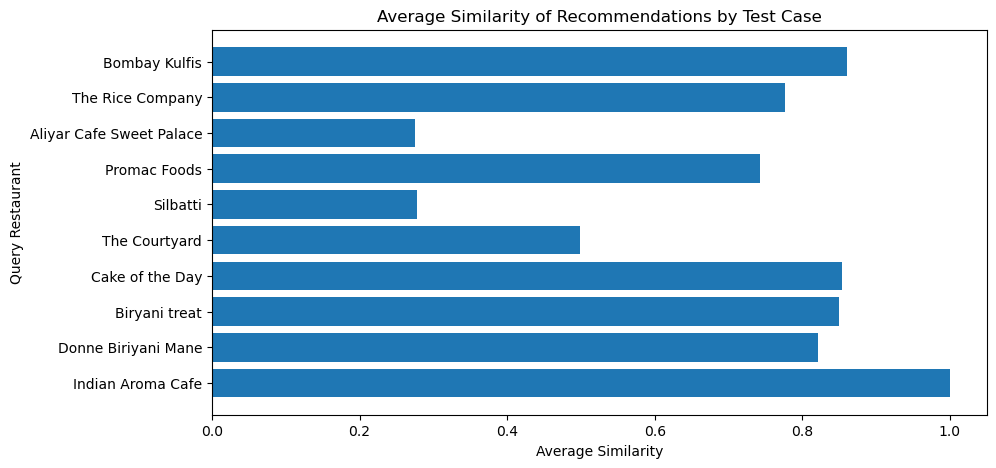

In [50]:
plt.figure(figsize=(10, 5))
plt.barh(qa_results["query_restaurant"], qa_results["avg_similarity"])
plt.xlabel("Average Similarity")
plt.ylabel("Query Restaurant")
plt.title("Average Similarity of Recommendations by Test Case")
plt.gca().invert_yaxis()
plt.show()

## 2. Average Weighted Rating of Recommendations

Weighted rating was used to assess the practical quality of recommendations by balancing customer ratings with restaurant popularity (number of votes).

### Key Findings

- **Silbatti** achieved the highest average weighted rating (~4.45), indicating that its recommendations were of particularly high quality.
- **Aliyar Cafe Sweet Palace** and **The Courtyard** also generated strong recommendation quality, with weighted ratings above 4.10.
- Most remaining restaurants produced recommendations within the 3.6 to 3.8 range, suggesting stable but moderate recommendation quality.

### Interpretation

The inclusion of weighted rating improves recommendation practicality by reducing the likelihood of recommending poorly rated establishments. While similarity ensures relevance, weighted rating ensures that recommendations maintain acceptable service quality.

This demonstrates that the hybrid ranking approach improves the usability of the recommender compared with relying on similarity alone.


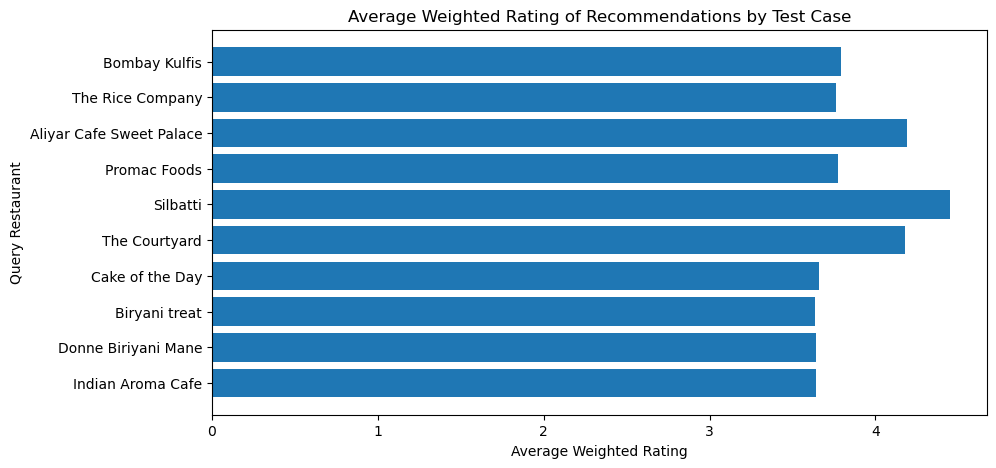

In [51]:
plt.figure(figsize=(10, 5))
plt.barh(qa_results["query_restaurant"], qa_results["avg_weighted_rating"])
plt.xlabel("Average Weighted Rating")
plt.ylabel("Query Restaurant")
plt.title("Average Weighted Rating of Recommendations by Test Case")
plt.gca().invert_yaxis()
plt.show()

## 3. Similarity vs Recommendation Quality Tradeoff

The scatter plot illustrates the relationship between semantic similarity and recommendation quality.

### Cluster 1: High Similarity, Moderate Quality

Examples:
- Indian Aroma Cafe
- Bombay Kulfis
- Cake of the Day
- Biryani Treat
- Donne Biriyani Mane

Interpretation:

These recommendations are highly relevant to the queried restaurant but offer only moderate weighted quality scores. This suggests that the recommender prioritizes textual similarity strongly, sometimes at the expense of restaurant quality.

---

### Cluster 2: Low Similarity, High Quality

Examples:
- Silbatti
- Aliyar Cafe Sweet Palace
- The Courtyard

Interpretation:

These recommendations are composed of highly rated restaurants, but their semantic similarity to the original query is weaker. This indicates that the weighted rating component can occasionally dominate ranking decisions.

---

### Cluster 3: Balanced Performance

Examples:
- Promac Foods
- The Rice Company
- Donne Biriyani Mane

Interpretation:

These represent the strongest recommendation cases because they balance both semantic relevance and recommendation quality. This region reflects the intended behavior of a practical hybrid recommender system.



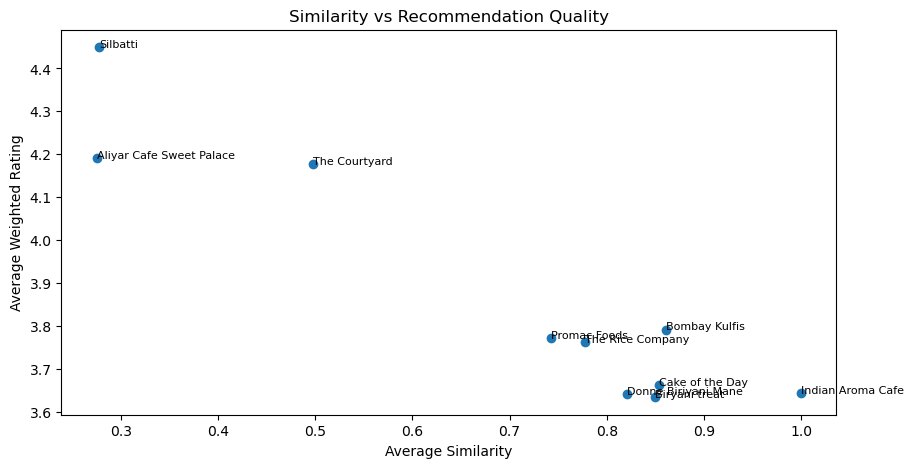

In [52]:
plt.figure(figsize=(10, 5))
plt.scatter(qa_results["avg_similarity"], qa_results["avg_weighted_rating"])

for _, row in qa_results.iterrows():
    plt.text(row["avg_similarity"], row["avg_weighted_rating"], row["query_restaurant"], fontsize=8)

plt.xlabel("Average Similarity")
plt.ylabel("Average Weighted Rating")
plt.title("Similarity vs Recommendation Quality")
plt.show()

## Overall Assessment

### Strengths

- Successfully retrieves semantically relevant restaurants for most test cases
- Produces consistently acceptable recommendation quality
- Hybrid ranking prevents recommending poorly rated restaurants
- Demonstrates practical applicability for restaurant discovery use cases

### Limitations

- Tradeoff exists between recommendation relevance and recommendation quality
- Some recommendations are overly similar but not necessarily high quality
- Others are high quality but insufficiently relevant to the user query
- Recommendation diversity is not explicitly optimized

---

## Recommendations for Improvement

To improve system performance, several enhancements can be considered:

### Refine Hybrid Ranking Weights

Current scoring may overemphasize similarity.

A more balanced scoring approach may be:

```python
final_score = (
    0.45 * similarity +
    0.35 * weighted_rating_scaled +
    0.20 * diversity_score
)
```

This would improve balance between relevance, quality, and recommendation diversity.

---

### Improve Feature Engineering

Text representation can be strengthened by assigning higher importance to stronger preference indicators.

Suggested weighted feature construction:

```python
content_features = (
    cuisines * 3 +
    dish_liked * 2 +
    rest_type * 2 +
    listed_in_type * 1 +
    location * 1
)
```

This would allow the recommender to better capture restaurant identity.

---

### Introduce Diversity Optimization

Highly repetitive recommendations reduce practical usefulness.

Diversity penalties can be introduced to reduce repeated cuisine or location recommendations.

---

### Add Location-Aware Boosting

Restaurant recommendations are often geographically sensitive.

Adding location preference weights can improve practical recommendation quality for users seeking nearby options.

---

## Conclusion

Overall, the proposed restaurant recommendation system demonstrates strong baseline performance as a hybrid content-based recommender.

The model effectively retrieves relevant restaurant recommendations while maintaining acceptable recommendation quality. However, further improvements in diversity optimization, ranking balance, and feature engineering would enhance its suitability for production-level deployment.